In [6]:

import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.2"

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian import (
    run_to_end_vmapped,
    InterpolatedSample2D,
    KrivanekLens,
    Biprism,
    sample_input_wave,
)
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import energy2wavelength, interaction_constant_CE
from temgym_core.aberrations import KrivanekCoeffs
from scipy.ndimage import map_coordinates


from libertem_holo.base.reconstr import reconstruct_frame, phase_unwrap
from libertem_holo.base.utils import HoloParams, remove_phase_ramp
from libertem_holo.base.align import get_slice_fft
from libertem_holo.base.filters import clipped
from libertem_ui.figure import ApertureFigure

jax.config.update("jax_enable_x64", True)

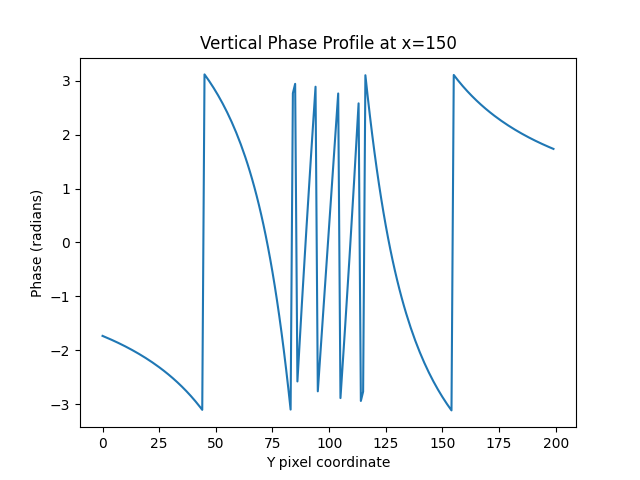

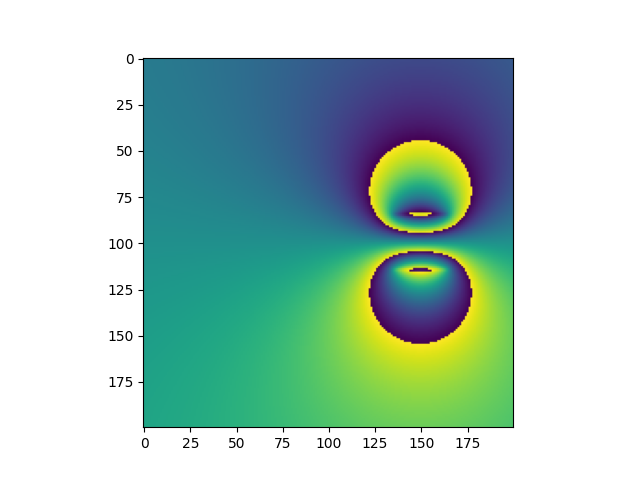

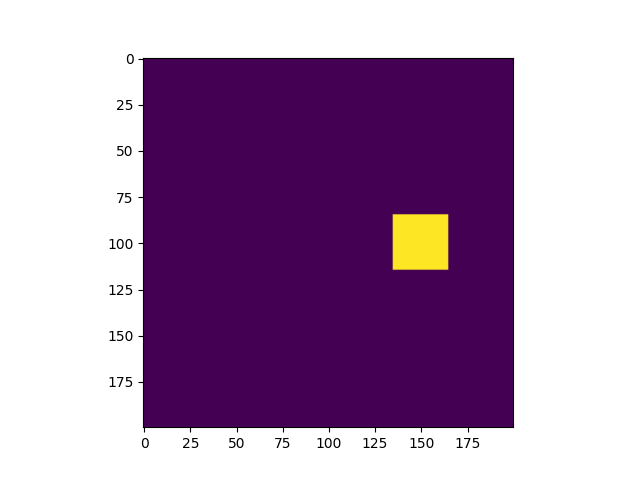

In [7]:
phase_cube = np.load('phase_cube.npy')
phase_cube_mask = np.load('phase_cube_mask.npy')

phase_cube_wave = 1 * np.exp(1j * phase_cube * 200)
plt.figure()
plt.imshow(np.angle(phase_cube_wave))

plt.figure()
plt.imshow(np.abs(phase_cube_wave) * phase_cube_mask)


x_coord = 150
phase_profile = np.angle(phase_cube_wave)[:, x_coord]

plt.figure()
plt.plot(phase_profile)
plt.title(f"Vertical Phase Profile at x={x_coord}")
plt.xlabel("Y pixel coordinate")
plt.ylabel("Phase (radians)")
plt.show()

In [8]:
def make_sample_interpolant(field, pixel_size):

    sample_y_coords = np.arange(-field.shape[0]//2,  field.shape[0] // 2) * pixel_size
    sample_x_coords = np.arange(-field.shape[1]//2,  field.shape[1] // 2) * pixel_size
    Y, X = np.meshgrid(sample_x_coords, sample_y_coords)

    amplitude_map = np.abs(field)
    
    amp_interpolator = InterpolatedSample2D.from_array(
        sample=amplitude_map.T,
        x_coords=sample_x_coords,
        y_coords=sample_y_coords,
        z=0.0,
        method='linear'
    ).interpolator
    
    phase_interpolator = InterpolatedSample2D.from_array(
        sample=np.angle(field).T,
        x_coords=sample_x_coords,
        y_coords=sample_y_coords,
        z=0.0,
        method='linear',
        extrap=0.0,
    ).interpolator

    return amp_interpolator, phase_interpolator

def resample_phase_object(
    phase,
    mask=None,
    src_pixel_size=1.0,
    target_shape=(100, 100),
    target_pixel_size=None,
    center=None,
    amp_inside=1.0,
    amp_outside=1.0,
    pad_to_shape=None,
    background_amp=None,   # Defaults to amp_outside if None
    background_phase=0.0,   # The value we fade TO at the very edge (usually 0)
    centre=(0.0, 0.0),
):
    """
    Embeds a phase patch and automatically tapers from the local edge value
    down to 'background_phase' (0) at the boundary of the padded region.
    """
    # --- 1. Setup Defaults ---
    src_h, src_w = phase.shape
    ty, tx = target_shape

    if pad_to_shape is None:
        pad_to_shape = target_shape

    py, px = pad_to_shape

    if background_amp is None:
        background_amp = amp_outside

    if mask is None:
        mask = np.ones_like(phase, dtype=np.float32)

    target_pixel_size_arr = np.asarray(target_pixel_size)
    if target_pixel_size_arr.ndim == 0:
        res_y = res_x = target_pixel_size_arr
    else:
        res_y, res_x = target_pixel_size

    # --- 2. Resample Inner Patch ---
    # We define the grid for the target window
    y = (np.arange(ty) - (ty - 1) / 2) * res_y
    x = (np.arange(tx) - (tx - 1) / 2) * res_x

    # CRITICAL CHANGE: Shift logic moved to padding step
    # Previously, centre shifted the sampling grid. Now we sample centered,
    # and shift the placement within the larger padded array.
    
    yy, xx = np.meshgrid(y, x, indexing="ij")
    v = yy / src_pixel_size + (src_h - 1) / 2
    u = xx / src_pixel_size + (src_w - 1) / 2
    coords = np.stack([v, u])

    # CRITICAL CHANGE 1: mode='nearest'
    # We ensure the edge pixels of the target_shape are populated with the
    # closest valid phase/mask value, rather than fading to 0 prematurely.
    phase_inner = map_coordinates(phase, coords, order=1, mode="nearest")
    mask_inner = map_coordinates(mask.astype(np.float32), coords, order=1, mode="nearest")

    # Amplitude inside target box
    amp_inner = amp_outside + (amp_inside - amp_outside) * mask_inner

    # --- 3. Pad and Extend Edges ---
    # Calculate padding size based on centre shift
    cy, cx = (0.0, 0.0) if centre is None else centre
    
    # Convert real-space shift to pixels
    shift_y_px = int(cy / res_y)
    shift_x_px = int(cx / res_x)

    # Base padding to center the target_shape within pad_to_shape
    base_pad_top = (py - ty) // 2
    base_pad_left = (px - tx) // 2
    
    # Apply shift
    pad_top = max(0, base_pad_top + shift_y_px)
    pad_bottom = max(0, py - ty - pad_top)
    pad_left = max(0, base_pad_left + shift_x_px)
    pad_right = max(0, px - tx - pad_left)

    pads = ((pad_top, pad_bottom), (pad_left, pad_right))

    # CRITICAL CHANGE 2: mode='edge'
    # This extends the local value at the boundary outwards.
    # If left edge is 2.5, the padding is filled with 2.5.
    phase_full = np.pad(phase_inner, pads, mode="edge")
    amp_full = np.pad(amp_inner, pads, mode="edge")

    # --- 4. Generate Edge-to-Zero Taper ---
    # We construct a mask that is 1.0 in the center and fades to 0.0 at the edges.

    def get_exact_ramp(n_pad_pixels, direction="up"):
        """Creates a cosine ramp from 0.0 to 1.0 (or 1.0 to 0.0)."""
        if n_pad_pixels <= 0:
            return np.array([], dtype=np.float32)

        # t goes from 0.0 to (N-1)/N
        t = np.arange(n_pad_pixels) / n_pad_pixels
        curve = 0.5 * (1.0 - np.cos(np.pi * t))

        return curve if direction == "up" else curve[::-1]

    # Build Y Taper
    ramp_top = get_exact_ramp(pad_top, "up")
    ramp_bottom = get_exact_ramp(pad_bottom, "down")
    middle_y = np.ones(ty)
    weight_y = np.concatenate([ramp_top, middle_y, ramp_bottom])

    # Build X Taper
    ramp_left = get_exact_ramp(pad_left, "up")
    ramp_right = get_exact_ramp(pad_right, "down")
    middle_x = np.ones(tx)
    weight_x = np.concatenate([ramp_left, middle_x, ramp_right])

    # 2D Taper Alpha
    taper_alpha = weight_y[:, None] * weight_x[None, :]

    # --- 5. Blend ---
    # This is the logic you asked for:
    # Value = Background + (Extended_Edge_Value - Background) * Taper
    # When Taper=1 (inside), Value = Extended_Edge_Value (original signal)
    # When Taper=0 (outside), Value = Background (0.0)

    final_amp = background_amp + (amp_full - background_amp) * taper_alpha
    final_phase = background_phase + (phase_full - background_phase) * taper_alpha

    final_field = final_amp * np.exp(1j * final_phase)

    # Return support for the valid inner region only
    final_support = np.pad(mask_inner, pads, mode="constant", constant_values=0.0)

    return final_field, final_support



In [9]:
def run_model(
    field,
    mask,
    pixel_size=0.5e-9,
    fringe_spacing=6e-9,
    voltage_eV=200e3,
    overlap_ratio=0.5,
    obj_magnification=-1,
    defocus=0.0,
    beam_waist=2e-9,
    overlap_factor=2.0,
    detector_rotation=0.0,
    show_plots=False,
):
    """
    Simulate a hologram with an optional quick look at the fields.
    """
    wavelength = energy2wavelength(voltage_eV)
    input_window_width_m = pixel_size * field.shape[0]
    print(f"Input window width: {input_window_width_m}")
    num_pixels = int(input_window_width_m / (pixel_size))

    amp_interpolator, phase_interpolator = make_sample_interpolant(
        field=field,
        pixel_size=pixel_size,
    )
    
    rays_in = sample_input_wave(
        voltage=voltage_eV,
        aperture_length=input_window_width_m * 1.0,
        waist=beam_waist,
        overlap_factor=overlap_factor,
        z0=defocus,
        amp_interpolator=amp_interpolator,
        phase_interpolator=phase_interpolator,
    )

    input_grid = Detector(
        z=0.0,
        pixel_size=(pixel_size, pixel_size),
        shape=(num_pixels, num_pixels),
    )

    input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_in, input_grid).block_until_ready()

    if show_plots:
        fig, axs = plt.subplots(1, 2)
        axs[0].imshow(np.abs(input_field), extent=input_grid.extent, cmap='inferno')
        axs[0].set_title('Input Field Amplitude')
        axs[1].imshow(np.angle(input_field), extent=input_grid.extent, cmap='twilight')
        axs[1].set_title('Input Field Phase')
        plt.tight_layout()

    # --- Calculate Geometry from Overlap and Fringe Spacing ---
    # We assume the biprism is placed exactly halfway between the back focal plane
    # and the image plane (a = b).
    #
    # 1. Biprism deflection angle (beta)
    #    fringe_spacing = wavelength / beta  =>  beta = wavelength / fringe_spacing
    biprism_deflection_angle = wavelength / fringe_spacing

    # 2. Image width on detector
    #    W_det = |M| * W_obj
    image_width = abs(obj_magnification) * input_window_width_m
    
    # Calculate overlap width from ratio
    overlap_width_on_detector = overlap_ratio * image_width
    print(f"Image width: {image_width:.3e} m, Overlap width: {overlap_width_on_detector:.3e} m ({overlap_ratio*100:.1f}%)")

    # 3. Calculate distance b (biprism to detector)
    #    Overlap = W_det - 2 * beta * b
    #    2 * beta * b = W_det - Overlap
    #    b = (W_det - Overlap) / (2 * beta)
    b = (image_width - overlap_width_on_detector) / (2 * biprism_deflection_angle)

    if b <= 0:
        raise ValueError(
            f"Calculated biprism-detector distance b={b} is non-positive. "
            "This usually means the requested overlap is too large (close to 100%) or fringe spacing is too small."
        )

    # 4. Calculate objective focal length f
    #    For negative magnification M: f = -2b / M
    #    (Derived from 2b = z2 - f and z2 = -M*z1, 1/f = 1/z1 + 1/z2)
    obj_focal_length = -2 * b / obj_magnification
    
    print(f"Calculated objective focal length: {obj_focal_length}")

    z1, z2 = calculate_z1_and_z2_from_M_and_f(
        M=obj_magnification,
        f=obj_focal_length,
    )
    z1, z2 = map(abs, (z1, z2))

    biprism_z = z1 + obj_focal_length + ((z1 + z2) - (z1 + obj_focal_length)) / 2
    a = biprism_z - (z1 + obj_focal_length)
    # b_check = ((z1 + z2) - biprism_z) # Should be equal to b

    # Recalculate b_def to be consistent with exact positions
    b_def = wavelength * (a + b) / (2 * fringe_spacing * a)

    aberration_coefficients = KrivanekCoeffs(
        phi12=0.0,
    )
    objective_lens = KrivanekLens(z=z1, focal_length=obj_focal_length, coeffs=aberration_coefficients)
    biprism = Biprism(z=biprism_z, strength=b_def, width=1e-15)

    detector = Detector(
        z=z1 + z2,
        pixel_size=(pixel_size, pixel_size),
        shape=(num_pixels, num_pixels),
        rotation=detector_rotation,
    )

    rays_out_with_sample = run_to_end_vmapped(rays_in, (objective_lens, biprism, detector))
    output_hologram = evaluate_gaussians_gpu_kernel_wrapper(rays_out_with_sample, detector).block_until_ready()

    # Add gaussian noise to simulate detector noise
    noise_level = 0*np.max(np.abs(output_hologram))
    noise = noise_level * (np.random.normal(size=output_hologram.shape) + 1j * np.random.normal(size=output_hologram.shape))
    output_hologram += noise
    
    if show_plots:
        fig, axs = plt.subplots(1, 1)
        axs.imshow(np.abs(output_hologram), cmap='gray', extent=detector.extent)
        #axs.plot(rays_out_with_sample[::1000].x, rays_out_with_sample[::1000].y, 'r.', markersize=1)
        axs.set_title('Hologram Intensity With Sample')

    return input_field, output_hologram


## Simulate holograms for multiple detector rotations
The cell below runs the microscope model for a list of sample cube rotations and stores the results so the reconstruction pipeline can iterate over them.


Input window width: 2.56e-07
Image width: 2.560e-07 m, Overlap width: 1.280e-07 m (50.0%)
Calculated objective focal length: 5.103802507578676e-05


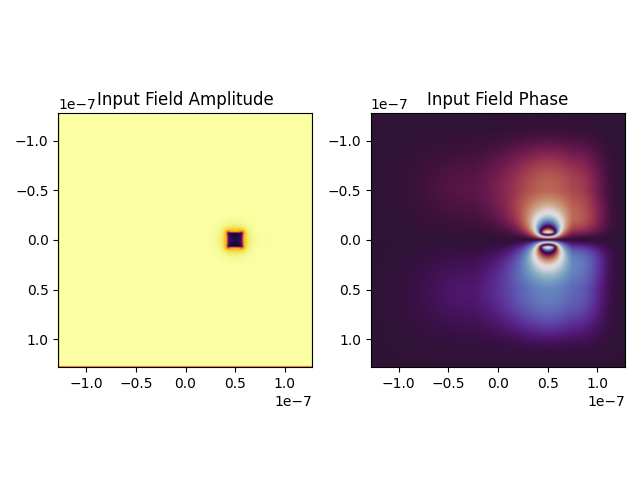

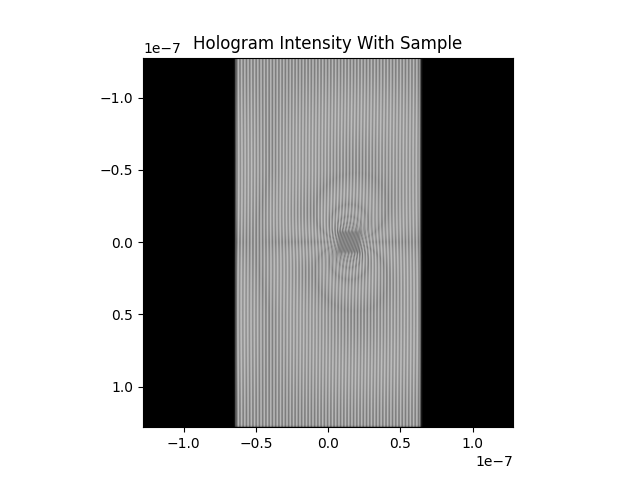

In [31]:
original_size = phase_cube.shape
original_pixel_size = 0.5e-9
target_size = (400, 400)
padded_shape = (1024, 1024)
target_pixel_size = original_size[0] * original_pixel_size / target_size[0]

field, mask = resample_phase_object(
    phase_cube * 200,
    mask=phase_cube_mask,
    src_pixel_size=original_pixel_size,
    target_shape=target_size,
    target_pixel_size=target_pixel_size,
    pad_to_shape=padded_shape,
    amp_inside=0.5,
    amp_outside=1.0,
    centre=(0.0, 25e-9)
)


base_simulation_kwargs = dict(
    field=field,
    mask=mask,
    pixel_size=target_pixel_size,
    voltage_eV=200e3,
    fringe_spacing=1e-9,
    beam_waist=1.0e-9,
    obj_magnification=-1,
    overlap_ratio=0.5,
    show_plots=True,
)

sample_rotations = [0]
results = {}

for rotation in sample_rotations:
    sim_kwargs = {**base_simulation_kwargs}
    input_field, output_hologram = run_model(**sim_kwargs)
    hologram = np.abs(output_hologram) ** 2
    results[rotation] = dict(
        input_field=input_field,
        output_hologram=output_hologram,
        hologram=hologram,
        sim_kwargs=sim_kwargs,
    )


## Helper functions for cropping and reconstruction
These functions let us reuse the same pipeline for every hologram in `results`.


In [32]:
def crop_hologram(hologram, start=129, size=256):
    row = slice(start, start + size)
    col = slice(start, start + size)
    return hologram[row, col], (row, col)


def reconstruct_hologram(hologram, ramp_roi=None, out_shape=None):
    if out_shape is None:
        out_shape = hologram.shape

    holo_params = HoloParams.from_hologram(
        hologram=hologram,
        out_shape=out_shape,
        central_band_mask_radius=20
    )
    slice_fft = get_slice_fft(sig_shape=hologram.shape, out_shape=out_shape)

    wave_obj = reconstruct_frame(
        frame=hologram,
        slice_fft=slice_fft,
        aperture=holo_params.aperture,
        sb_pos=holo_params.sb_position,
    )

    phase = phase_unwrap(np.angle(wave_obj))
    # phase, _, _ = remove_phase_ramp(phase, roi=ramp_roi[0])
    phase = phase - np.min(np.abs(phase))
    fft = np.abs(np.fft.fft2(hologram))

    return dict(
        wave_obj=wave_obj,
        phase=phase,
        fft=fft,
        holo_params=holo_params,
        slice_fft=slice_fft,
        sb_pos=holo_params.sb_position,
    )


def phase_cross_sections(phase, ground_truth_phase, measured_phase_roi, ground_truth_phase_roi):
    measured_phase = np.mean(phase[measured_phase_roi[0]], axis=0)
    measured_phase = measured_phase - np.mean(measured_phase)

    gt_phase = np.mean(ground_truth_phase[ground_truth_phase_roi[0]], axis=0)
    gt_phase = gt_phase - np.mean(gt_phase)

    return measured_phase, gt_phase


def process_all_holograms(
    results,
    crop_start,
    crop_size,
    ramp_roi,
    measured_phase_roi,
    ground_truth_phase_roi,
):
    """Crop, reconstruct, and extract cross-sections for every hologram."""
    processed = {}
    for rotation, data in results.items():
        cropped_hologram, _ = crop_hologram(
            data["hologram"], start=crop_start, size=crop_size
        )
        reconstruction = reconstruct_hologram(
            cropped_hologram,
            ramp_roi=ramp_roi,
            out_shape=cropped_hologram.shape,
        )

        input_phase = phase_unwrap(np.angle(data["input_field"]))
        measured_phase, ground_truth_phase = phase_cross_sections(
            reconstruction["phase"],
            input_phase,
            measured_phase_roi,
            ground_truth_phase_roi,
        )

        processed[rotation] = {
            **reconstruction,
            "cropped_hologram": cropped_hologram,
            "input_field_phase": input_phase,
            "measured_phase_cross_section": measured_phase,
            "ground_truth_phase_cross_section": ground_truth_phase,
        }

    return processed


## Pick ramp ROI once on a reference hologram
Draw a rectangle over a fringe-only area; the same ROI will be reused for every rotation.


In [33]:
crop_start = 250
crop_size = 500
reference_rotation = sample_rotations[0]

reference_hologram, crop_slices = crop_hologram(
    results[reference_rotation]["hologram"], start=crop_start, size=crop_size
)
out_shape = reference_hologram.shape

fig = ApertureFigure.new(reference_hologram)
fig.add_mask_tools(rectangles=True, polygons=False)
fig.layout


BokehModel(combine_events=True, render_bundle={'docs_json': {'03ff9e44-bcba-4eeb-a7c1-356a214bc172': {'version…

In [34]:
ramp_roi = fig.get_mask_rect_as_slices(reference_hologram.shape)
print("Ramp ROI:", ramp_roi, "Cropped shape:", reference_hologram.shape)


Ramp ROI: [] Cropped shape: (500, 500)



## Reconstruct the reference hologram and select measurement ROIs
Use the figures to choose the sideband position, the measured phase ROI, and a ground-truth ROI on the simulated input field. Those choices will be re-used for all holograms.


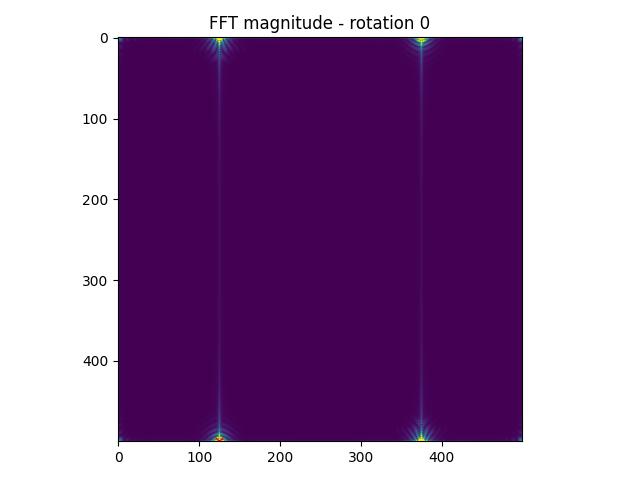

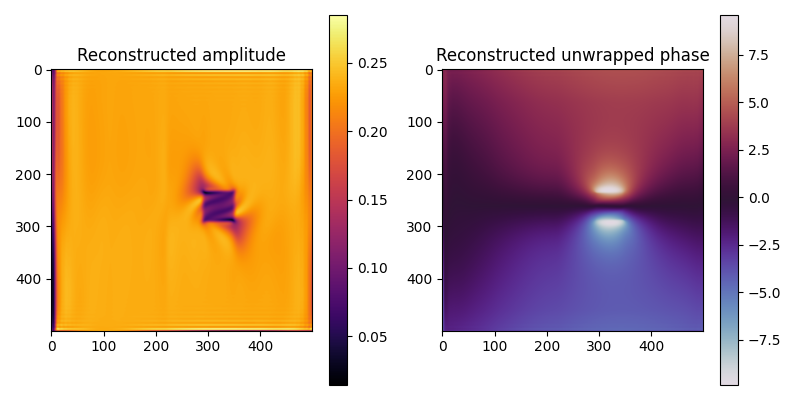

In [35]:
reference_reconstruction = reconstruct_hologram(
    reference_hologram,
    ramp_roi=None,
    out_shape=out_shape,
)

sb_pos = reference_reconstruction["sb_pos"]

plt.figure()
plt.imshow(
    reference_reconstruction["fft"],
    vmin=np.min(clipped(reference_reconstruction["fft"])),
    vmax=np.max(clipped(reference_reconstruction["fft"])),
)
plt.plot(sb_pos[1], sb_pos[0], 'rx')
plt.title(f"FFT magnitude - rotation {reference_rotation}")
plt.tight_layout()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
im0 = axs[0].imshow(np.abs(reference_reconstruction["wave_obj"]), cmap='inferno')
axs[0].set_title('Reconstructed amplitude')
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(reference_reconstruction["phase"], cmap='twilight')
axs[1].set_title('Reconstructed unwrapped phase')
fig.colorbar(im1, ax=axs[1])
plt.tight_layout()


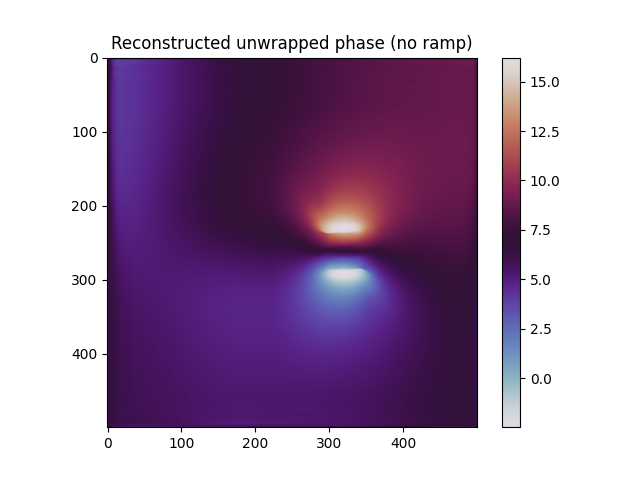

In [30]:
phase_no_ramp, _, _ = remove_phase_ramp(
    reference_reconstruction["phase"])

plt.figure()
plt.imshow(phase_no_ramp, cmap='twilight')
plt.title('Reconstructed unwrapped phase (no ramp)')
plt.colorbar()